In [1]:
!pip install --upgrade scikit-learn

^C


In [ ]:
!pip install -q pandas numpy matplotlib seaborn phik scikit-learn shap --

In [ ]:
!pip install --upgrade matplotlib shap seaborn

     |████████████████████████████████| 8.3 MB 2.0 MB/s eta 0:00:01
     |████████████████████████████████| 294 kB 25.4 MB/s eta 0:00:01
     |████████████████████████████████| 321 kB 86.0 MB/s eta 0:00:01
     |████████████████████████████████| 4.8 MB 74.3 MB/s eta 0:00:01
     |████████████████████████████████| 19.5 MB 45.2 MB/s eta 0:00:01
     |████████████████████████████████| 3.7 MB 59.0 MB/s eta 0:00:01
     |████████████████████████████████| 43.9 MB 96.2 MB/s eta 0:00:01
     |████████████████████████████████| 17.3 MB 69.0 MB/s eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.1
    Uninstalling numpy-1.21.1:
      Successfully uninstalled numpy-1.21.1
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.39.0
    Uninstalling llvmlite-0.39.0:
      Successfully uninstalled llvmlite-0.39.0
  Attempting uninstall: numba
    Found existing installation: numba 0.56.0
    Uninstalling numba-0.56.0:
      Successfully uninst

In [ ]:
pip install -U scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
from phik import phik_matrix
import shap

In [ ]:
try:
    df_train_job_satisfaction_rate = pd.read_csv('/datasets/market_file.csv')
    df_test_features = pd.read_csv('/datasets/market_money.csv')
    market_time_df = pd.read_csv('/datasets/market_time.csv')
    money_df = pd.read_csv('/datasets/money.csv', sep=';', decimal=',')
except:
    market_file_df = pd.read_csv('https://code.s3.yandex.net/datasets/market_file.csv')
    market_money_df = pd.read_csv('https://code.s3.yandex.net/datasets/market_money.csv')
    market_time_df = pd.read_csv('https://code.s3.yandex.net/datasets/market_time.csv')
    money_df = pd.read_csv('https://code.s3.yandex.net/datasets/money.csv', sep=';', decimal=',')

In [ ]:
display(market_file_df.head())
display(market_money_df.head())
display(market_time_df.head())
money_df.head()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


**Вывод по разделу 1.**

Посмотрели и поняли задачу проекта. Подключили необходимые библиотеки (по ходу выполнения будет добавлять их). Считали данные, познакомимся с ними в следующем разделе.

## **Предобработка данных**

До начала изучения данных поменяем названия столбцов на англ язык - для универсальности кода, заодно приведем все к нижнему регистру.

Index(['id', 'Покупательская активность', 'Тип сервиса', 'Разрешить сообщать',
       'Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность',
       'Акционные_покупки', 'Популярная_категория',
       'Средний_просмотр_категорий_за_визит',
       'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса',
       'Страниц_за_визит'],
      dtype='object')
Index(['id', 'Период', 'Выручка'], dtype='object')
Index(['id', 'Период', 'минут'], dtype='object')


Index(['id', 'Прибыль'], dtype='object')

In [ ]:
market_file_df.columns = ['id', 'customer_activity', 'service_type', 'notification',
       'market_activity_halfyaer', 'market_activity_month', 'duration_day',
       'promotion_purch', 'popular_category',
       'mean_category_per_visit_month',
       'unpaid_purch_per_quarter', 'service_error',
       'pages_per_visit_per_quarter']
market_money_df.columns = ['id', 'period', 'revenue']
market_time_df.columns = ['id', 'period', 'minuts_on_site']
money_df.columns = ['id', 'profit']

In [ ]:
print(market_file_df.columns)
print(market_money_df.columns)
print(market_time_df.columns)
money_df.columns

Index(['id', 'customer_activity', 'service_type', 'notification',
       'market_activity_halfyaer', 'market_activity_month', 'duration_day',
       'promotion_purch', 'popular_category', 'mean_category_per_visit_month',
       'unpaid_purch_per_quarter', 'service_error',
       'pages_per_visit_per_quarter'],
      dtype='object')
Index(['id', 'period', 'revenue'], dtype='object')
Index(['id', 'period', 'minuts_on_site'], dtype='object')


Index(['id', 'profit'], dtype='object')

**Market_file**

Начну с написания небольшого кол-ва функций, которые помогут при дальнейшей обработке.

In [ ]:
def express_analysis(df):
    data = {
        'type' : df.dtypes,
        'count_dupl' : [],
        'count_nan' : []
    }
    
    for x in df.columns:
        data['count_dupl'].append(df[x].duplicated().sum())
        data['count_nan'].append(df[x].isna().sum())
    
    return pd.DataFrame(data)

In [ ]:
def cat_col_analysis(df):
    cat_col = df.select_dtypes(exclude='number').columns.tolist()
    cat_info = {
        'unique_count' : []
    }
    
    #все строковые данные очистим от лишних символов, пробелов и заглавных букв
    for x in cat_col: 
        df[x]= df[x].str.lower()
        df[x]= df[x].replace(r' ', '_', regex=True)
        df[x]= df[x].replace('%','', regex=True)
        cat_info['unique_count'].append(dict(Counter(df[x])))
            
    return pd.DataFrame(cat_info, index=cat_col) 

In [ ]:
def num_col_analysis(df):
    num_col = df.select_dtypes(include='number').columns.drop('id').tolist()
    cols_per_row = (len(num_col) + 2 - 1) // 2
    fig, axes = plt.subplots(nrows=2, ncols=cols_per_row, figsize=(15, 6), sharey=False)
    
    
    for ax in axes.ravel()[len(num_col):]:
        ax.remove()
        
    for col_name, ax in zip(num_col, axes.ravel()):
        ax.boxplot(df[col_name])
        ax.set_title(col_name)
        ax.set_ylabel('Значения')
        ax.grid(True)
    plt.tight_layout()
    plt.show()
    
    return df[num_col].describe()

In [ ]:
display(express_analysis(market_file_df))
market_file_df.head()

,type,count_dupl,count_nan
id,int64,0,0
customer_activity,object,1298,0
service_type,object,1297,0
notification,object,1298,0
market_activity_halfyaer,float64,1259,0
market_activity_month,int64,1297,0
duration_day,int64,642,0
promotion_purch,float64,1258,0
popular_category,object,1294,0
mean_category_per_visit_month,int64,1294,0


,id,customer_activity,service_type,notification,market_activity_halfyaer,market_activity_month,duration_day,promotion_purch,popular_category,mean_category_per_visit_month,unpaid_purch_per_quarter,service_error,pages_per_visit_per_quarter
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


Нигде нет пропусков - это прекрасно

По типам данных - вроде бы все хорошо

Дубликаты - главное, что в id нет повторов, остальные повторы допустимы.

Теперь изучим категориальные данные и числовые отдельно.

In [ ]:
cat_col_analysis(market_file_df)

,unique_count
customer_activity,"{'снизилась': 498, 'прежний_уровень': 802}"
service_type,"{'премиум': 376, 'стандартт': 10, 'стандарт': ..."
notification,"{'да': 962, 'нет': 338}"
popular_category,"{'товары_для_детей': 330, 'домашний_текстиль':..."


In [ ]:
market_file_df.service_type = market_file_df.service_type.replace('стандартт', 'стандарт')
market_file_df.service_type.unique()

array(['премиум', 'стандарт'], dtype=object)

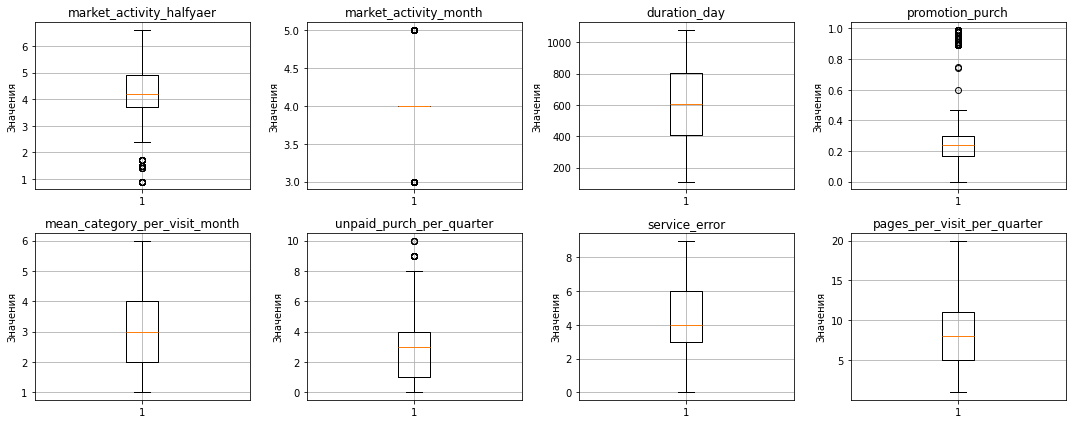

,market_activity_halfyaer,market_activity_month,duration_day,promotion_purch,mean_category_per_visit_month,unpaid_purch_per_quarter,service_error,pages_per_visit_per_quarter
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.00000,1300.000000,1300.000000,1300.000000
mean,4.253769,4.011538,601.898462,0.319808,3.27000,2.840000,4.185385,8.176923
std,1.014814,0.696868,249.856289,0.249843,1.35535,1.971451,1.955298,3.978126
min,0.900000,3.000000,110.000000,0.000000,1.00000,0.000000,0.000000,1.000000
25%,3.700000,4.000000,405.500000,0.170000,2.00000,1.000000,3.000000,5.000000
50%,4.200000,4.000000,606.000000,0.240000,3.00000,3.000000,4.000000,8.000000
75%,4.900000,4.000000,806.000000,0.300000,4.00000,4.000000,6.000000,11.000000
max,6.600000,5.000000,1079.000000,0.990000,6.00000,10.000000,9.000000,20.000000


In [ ]:
num_col_analysis(market_file_df)

По количественным: активность от маркета - есть несколько слишком низких значений, но не настолько сильно отличающихся, чтобы считать аномалией. Активность за месяц - дискретное значение с небольшой длиной, а не непрерывная, так что тут boxplot лишний, но легче его сделать, чем исключать. Покупки по акциям - достаточно много людей с высоким показателем, но это нормально. Дальше тоже все нормально (как и с активность, не покупка 10 товаров при максимальном 8 - не такое большое отклонение для исключения, ладно было бы 100)

**Market_money**

**Market_time**

In [ ]:
display(market_time_df.head())
express_analysis(market_time_df)

,id,period,minuts_on_site
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


,type,count_dupl,count_nan
id,int64,1300,0
period,object,2598,0
minuts_on_site,int64,2580,0


В периоде опечатка, остальное окей, сейчас посмотрим внимательнее.

In [ ]:
cat_col_analysis(market_time_df)

,unique_count
period,"{'текущий_месяц': 1300, 'предыдцщий_месяц': 1300}"


In [ ]:
market_time_df['period'] = market_time_df['period'].replace('предыдцщий_месяц', 'предыдущий_месяц')
market_time_df['period'].unique()

array(['текущий_месяц', 'предыдущий_месяц'], dtype=object)

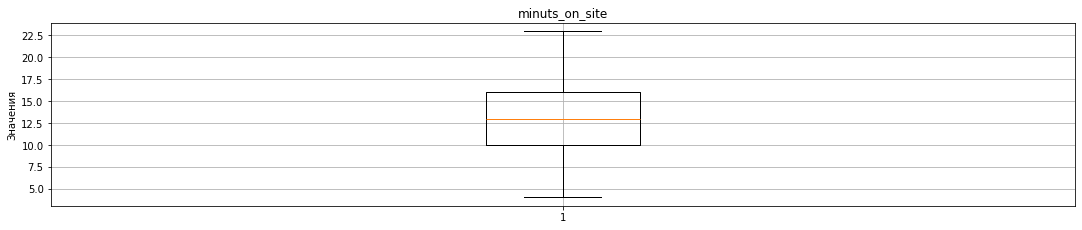

,minuts_on_site
count,2600.000000
mean,13.336154
std,4.080198
min,4.000000
25%,10.000000
50%,13.000000
75%,16.000000
max,23.000000


In [ ]:
num_col_analysis(market_time_df)

Категории подправили, количественные окей.

**Money_df**

In [ ]:
express_analysis(money_df)

,type,count_dupl,count_nan
id,int64,0,0
profit,float64,900,0


In [ ]:
cat_col_analysis(money_df)

,unique_count


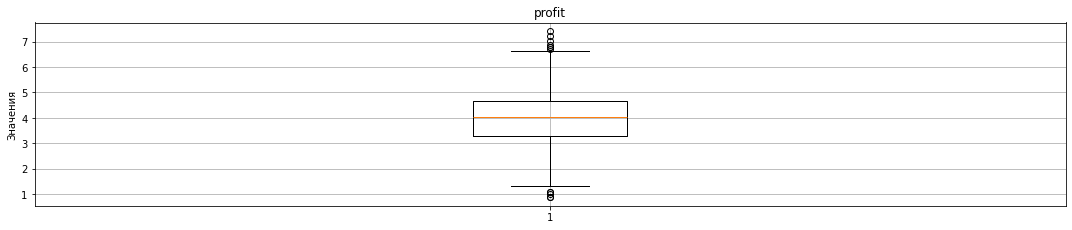

,profit
count,1300.000000
mean,3.996631
std,1.013722
min,0.860000
25%,3.300000
50%,4.045000
75%,4.670000
max,7.430000


In [ ]:
num_col_analysis(money_df)

Все окей, с предобработкой закончили. Значения прибыли отличаются от значения выручки из market_df, но ничего не будем с этим делать, потому что нам не известны единицы измерения, а может данные вообще как-то закодированы от магазина. Главное - тенденции сохраняются.

**Вывод по разделу 2.**

Изучили все df. В market_file был обнаружен не явный дубликат. В market_money нашли выбросы и удалили их. В market_time нашли опечатку и исправили ее. В money_df вроде бы все хорошо

## **Исследовательский анализ**

На этом этапе нам необходимо проведите исследовательский анализ данных из каждой таблицы. Отобрать клиентов с покупательской активностью не менее трёх месяцев, то есть таких, которые что-либо покупали в этот период. Оформите выводы по результатам шага.

В данном случае обработку тоже слегка автоматизируем. Для категориальных значений выведем круговые диаграммы. Для числовых гист, боксплот и дескрайб.

In [ ]:
def visual_analysis(df, discrete_threshold=20):
    for col in df.drop(columns=['id']).columns:
        if df[col].dtype == 'object':
            value_counts = df[col].value_counts()
            plt.figure(figsize=(6, 4))
            plt.pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%', startangle=90)
            plt.title(f'{col} - Pie')
            plt.axis('equal')  
            plt.show()
            print(value_counts)
        
        else:
            unique_vals = df[col].nunique()
            
            if unique_vals <= discrete_threshold:
                plt.figure(figsize=(6, 4))
                sns.countplot(x=col, data=df)
                plt.title(f'{col} - Countplot')
                plt.xlabel(col)
                plt.ylabel("Частота")
                plt.show()
            else:
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [2, 1]})
                sns.histplot(data=df, x=col, bins=20, ax=ax1, kde=True)
                ax1.set_title(f'{col} - Histogram')
                ax1.set_xlabel(col)
                ax1.set_ylabel('Частота')

                sns.boxplot(data=df, y=col, ax=ax2)
                ax2.set_title(f'{col} - BoxPlot')
                ax2.set_xlabel(col)
                
                plt.tight_layout()
                plt.show()

            print(f"\nОписание для {col}:")
            print(df[col].describe())

**Market_file**

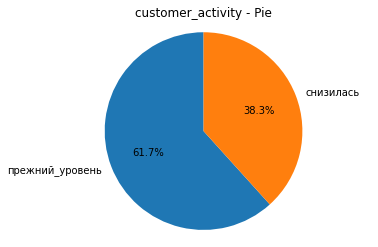

прежний_уровень    802
снизилась          498
Name: customer_activity, dtype: int64


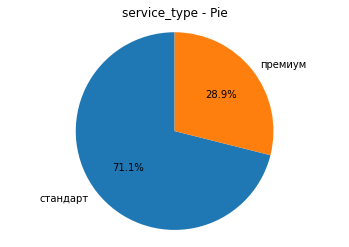

стандарт    924
премиум     376
Name: service_type, dtype: int64


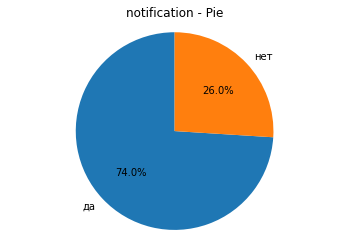

да     962
нет    338
Name: notification, dtype: int64


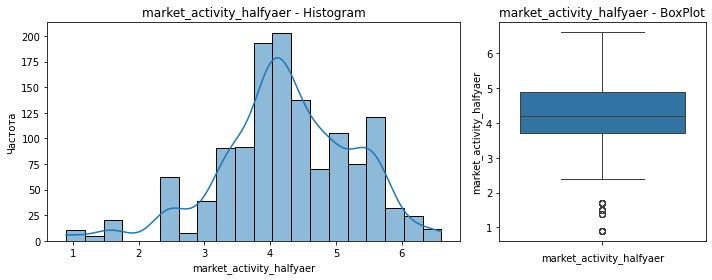


Описание для market_activity_halfyaer:
count    1300.000000
mean        4.253769
std         1.014814
min         0.900000
25%         3.700000
50%         4.200000
75%         4.900000
max         6.600000
Name: market_activity_halfyaer, dtype: float64


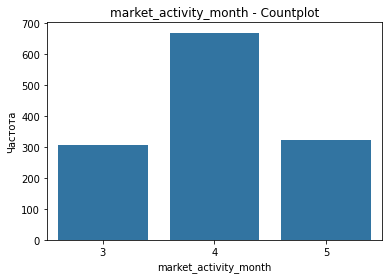


Описание для market_activity_month:
count    1300.000000
mean        4.011538
std         0.696868
min         3.000000
25%         4.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: market_activity_month, dtype: float64


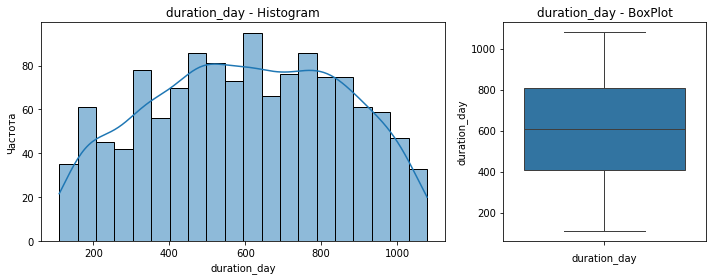


Описание для duration_day:
count    1300.000000
mean      601.898462
std       249.856289
min       110.000000
25%       405.500000
50%       606.000000
75%       806.000000
max      1079.000000
Name: duration_day, dtype: float64


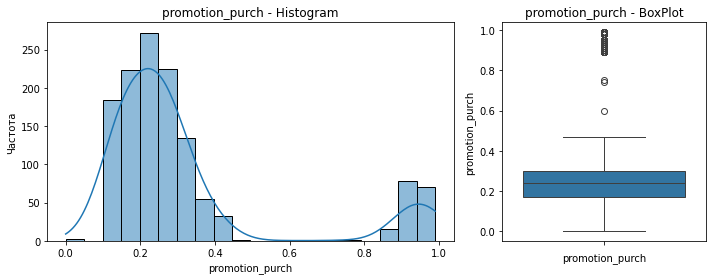


Описание для promotion_purch:
count    1300.000000
mean        0.319808
std         0.249843
min         0.000000
25%         0.170000
50%         0.240000
75%         0.300000
max         0.990000
Name: promotion_purch, dtype: float64


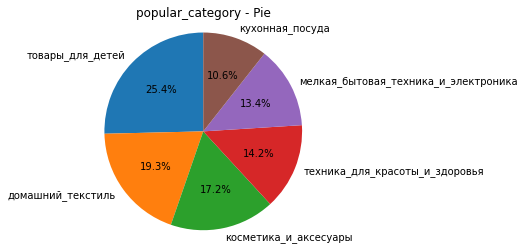

товары_для_детей                        330
домашний_текстиль                       251
косметика_и_аксесуары                   223
техника_для_красоты_и_здоровья          184
мелкая_бытовая_техника_и_электроника    174
кухонная_посуда                         138
Name: popular_category, dtype: int64


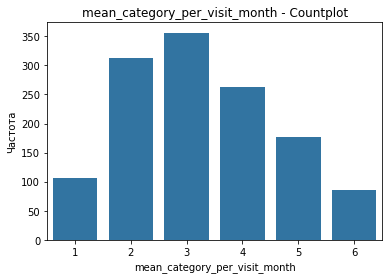


Описание для mean_category_per_visit_month:
count    1300.00000
mean        3.27000
std         1.35535
min         1.00000
25%         2.00000
50%         3.00000
75%         4.00000
max         6.00000
Name: mean_category_per_visit_month, dtype: float64


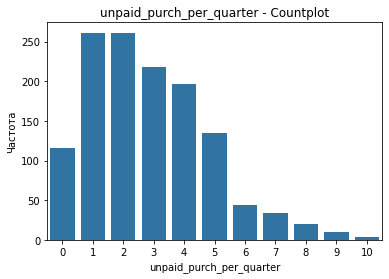


Описание для unpaid_purch_per_quarter:
count    1300.000000
mean        2.840000
std         1.971451
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: unpaid_purch_per_quarter, dtype: float64


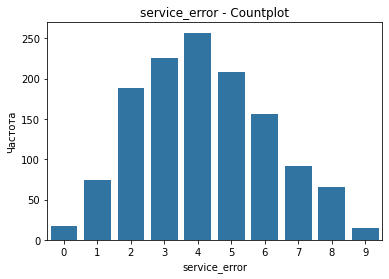


Описание для service_error:
count    1300.000000
mean        4.185385
std         1.955298
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max         9.000000
Name: service_error, dtype: float64


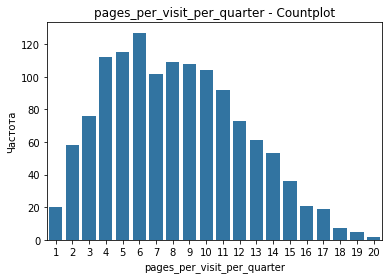


Описание для pages_per_visit_per_quarter:
count    1300.000000
mean        8.176923
std         3.978126
min         1.000000
25%         5.000000
50%         8.000000
75%        11.000000
max        20.000000
Name: pages_per_visit_per_quarter, dtype: float64


In [ ]:
visual_analysis(market_file_df)

- Тип сервиса распределен следующим образом: 71% стандартная, 29% пермиум;
- дали разрешения на уведомления практически так же четверь - 26% против 74%;
- активность маркета за последние полгода - большая часть находится в диапазоне от 3.7 до 4.9.Значений до 2.4 совсем немного;
- активность за последний месяц - 3шт (308 значений), 4шт (669знач) и 5 шт (323знач);
- самый недавний присоединившийся к сервису человек уже 110 дней на сайте - явно проблема с новыми клиентами. Большая часть людей пользуется сервисом 405-806 дней;
- количество акционных покупок у пользователей - чаще всего составляет 17 - 30%. Есть пользователи с нулевым значением, а так же заметный всплеск на значениях 88%-100%. Интересно, как людям удается покупать только акционку и не заглядываться на остальное. Их явно можно заманить только скидками;
- популярные категории распределены достаточно равномерно. Лидер - товары для детей, аутсайдер - кухонная посуда;
- среднее количество категорий стермится к номральному с медианой в 3. Чем больше - тем реже, чем меньше, тем реже;
- количество неоплаченных покупок выглядит как логнормальное распредление - с увеличением числа - идет стремительное уменьшение. Лидеры 1 и 2 товара (по 261 разу);
- распредление количества ошибок, коснувшихся покупателя выглядит, как номральное с медианой 4, мин=0, макс=9;
- кол-во просмотренных страниц за визит распредилилось следующим образом - большинство с 5 до 11, минимум в единице, максимум 20.

**Market_money**

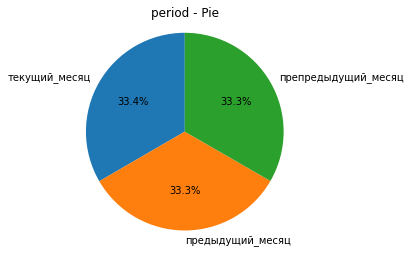

текущий_месяц          1299
предыдущий_месяц       1297
препредыдущий_месяц    1297
Name: period, dtype: int64


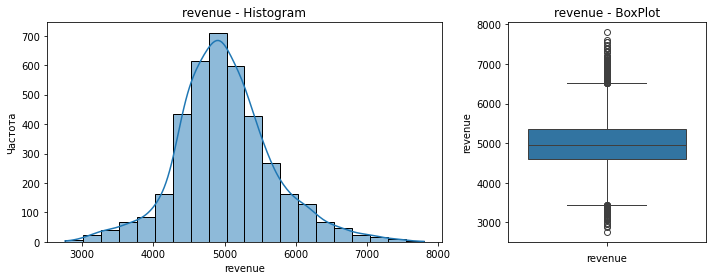


Описание для revenue:
count    3893.000000
mean     5007.282918
std       679.724898
min      2758.700000
25%      4592.000000
50%      4959.000000
75%      5363.000000
max      7799.400000
Name: revenue, dtype: float64


In [ ]:
visual_analysis(market_money_df)

В маркет market_file данные следующие:

- Периоды раные - везде по трети
- Сумма выручки в большей части - от 4591 до 5363. Равномерно есть и больше, и меньше.

**Market_time**

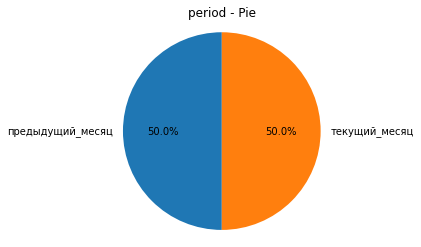

предыдущий_месяц    1300
текущий_месяц       1300
Name: period, dtype: int64


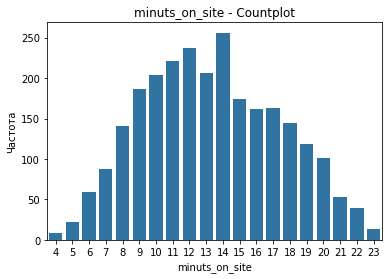


Описание для minuts_on_site:
count    2600.000000
mean       13.336154
std         4.080198
min         4.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        23.000000
Name: minuts_on_site, dtype: float64


In [ ]:
visual_analysis(market_time_df)

В данных времени картина следующая:

- Период распредлен 50/50.
- Минуты проведенные на сайте распредлены, практически, равномерно со сердним в 13, минимум в 4 и максимумом в 23.

**Money**

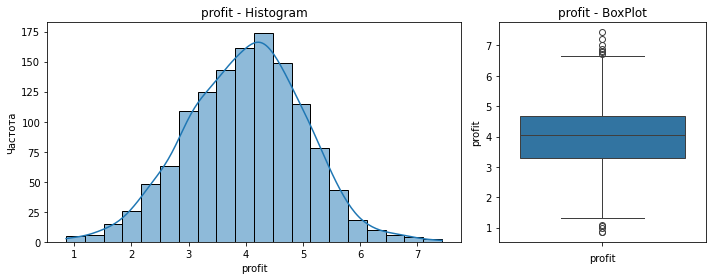


Описание для profit:
count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: profit, dtype: float64


In [ ]:
visual_analysis(money_df)

В среднемесячной прибыли:

- Прибыль распредлена равномерно с центром в 4, минимум в 1.33 и максимум в 6.65. Встерчаются занчения и больше, и меньше, без явных вбросов.

**Вывод по разделу 3.**

Провели анализ и выявили следующее: 
- Преобладающий тип сервиса - стандартный;
- рассылку готова получать четверть пользователей;
- средняя активность маркета за последние полгода и за месяц около 4;
- к сервису давно не присоединялись новые пользователи;
- большая часть ползователей использует сервис от 1,5 лет до 2,5;
- в среднем 20% покупок -акционные предложения;
- больше всего пользуются спросом товары для детей, но не с большим отрывом от остальных категорий;
- среднее количество просмотра разных категорий около 3;
- количество неоплаченных покупок - 1,2 штуки за последние 3 месяца;
- каждый покупатель в среднем страдает от ошибок около 4 раз;
- просмотры различных страниц в среднем 8;
- все анализируемые периоды распредлены в данных равномерно;
- большая часть выручки лежит в диапазоне от 4500 до 5400;
- на сайте проводят в среднем 13 минут;
- а прибыль получают в среднем со значением равным четырем.

## **Объединение таблиц**

В данном разделе нам необходимо Объедините таблицы market_file.csv, market_money.csv, market_time.csv. Данные о прибыли из файла money.csv при моделировании не понадобятся.

Учитывайте, что данные о выручке и времени на сайте находятся в одном столбце для всех периодов. В итоговой таблице сделайте отдельный столбец для каждого периода.

In [ ]:
market_money_df_pv = market_money_df.pivot_table(
    index='id', columns='period', values='revenue', aggfunc='sum').reset_index()
market_money_df_pv.columns = ['id','last_month_revenue', 'two_month_ago_revenue', 'current_month_revenue']

market_time_df_pv = market_time_df.pivot_table(
    index='id', columns='period', values='minuts_on_site', aggfunc='sum').reset_index()
market_time_df_pv.columns = ['id','last_month_minuts', 'current_month_minuts']

display(market_money_df_pv.head())
market_time_df_pv.head()

,id,last_month_revenue,two_month_ago_revenue,current_month_revenue
0,215348,NaN,NaN,3293.1
1,215349,5216.0,4472.0,4971.6
2,215350,5457.5,4826.0,5058.4
3,215351,6158.0,4793.0,6610.4
4,215352,5807.5,4594.0,5872.5


,id,last_month_minuts,current_month_minuts
0,215348,13,14
1,215349,12,10
2,215350,8,13
3,215351,11,13
4,215352,8,11


In [ ]:
print(market_money_df_pv.info())
market_time_df_pv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1300 non-null   int64  
 1   last_month_revenue     1297 non-null   float64
 2   two_month_ago_revenue  1297 non-null   float64
 3   current_month_revenue  1299 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 40.8 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   id                    1300 non-null   int64
 1   last_month_minuts     1300 non-null   int64
 2   current_month_minuts  1300 non-null   int64
dtypes: int64(3)
memory usage: 30.6 KB


In [ ]:
market_money_df_pv = market_money_df_pv.dropna()

In [ ]:
full_df = pd.merge(market_file_df, market_money_df_pv, on='id', how='inner')
full_df = pd.merge(full_df, market_time_df_pv, on='id', how='inner')
full_df.isna().sum()

id                               0
customer_activity                0
service_type                     0
notification                     0
market_activity_halfyaer         0
market_activity_month            0
duration_day                     0
promotion_purch                  0
popular_category                 0
mean_category_per_visit_month    0
unpaid_purch_per_quarter         0
service_error                    0
pages_per_visit_per_quarter      0
last_month_revenue               0
two_month_ago_revenue            0
current_month_revenue            0
last_month_minuts                0
current_month_minuts             0
dtype: int64

In [ ]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1296 entries, 0 to 1295
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             1296 non-null   int64  
 1   customer_activity              1296 non-null   object 
 2   service_type                   1296 non-null   object 
 3   notification                   1296 non-null   object 
 4   market_activity_halfyaer       1296 non-null   float64
 5   market_activity_month          1296 non-null   int64  
 6   duration_day                   1296 non-null   int64  
 7   promotion_purch                1296 non-null   float64
 8   popular_category               1296 non-null   object 
 9   mean_category_per_visit_month  1296 non-null   int64  
 10  unpaid_purch_per_quarter       1296 non-null   int64  
 11  service_error                  1296 non-null   int64  
 12  pages_per_visit_per_quarter    1296 non-null   i

**Вывод по разделу 4.**

Данные объединили, от тех, которые оказались пустыми и нет информации для подстановки удалили.

In [ ]:
full_df.customer_activity.unique()

array(['снизилась', 'прежний_уровень'], dtype=object)

## **Корреляционный анализ**

Начнем с исследования уже объединенных данных.

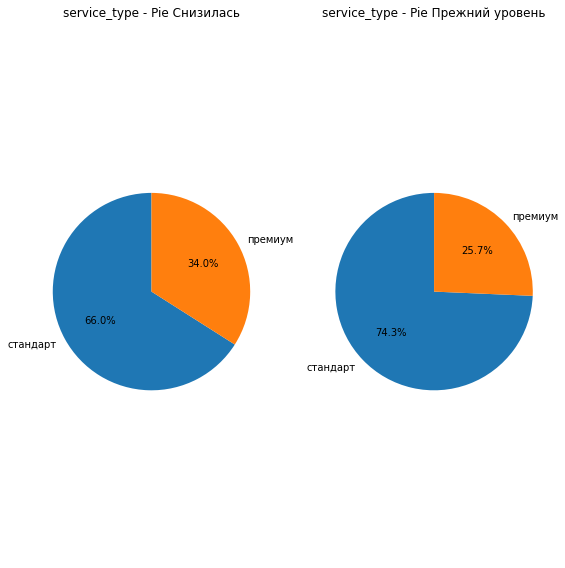

Value counts for service_type (Снизилась):
стандарт    326
премиум     168
Name: service_type, dtype: int64
Value counts for service_type (Прежний уровень):
стандарт    596
премиум     206
Name: service_type, dtype: int64


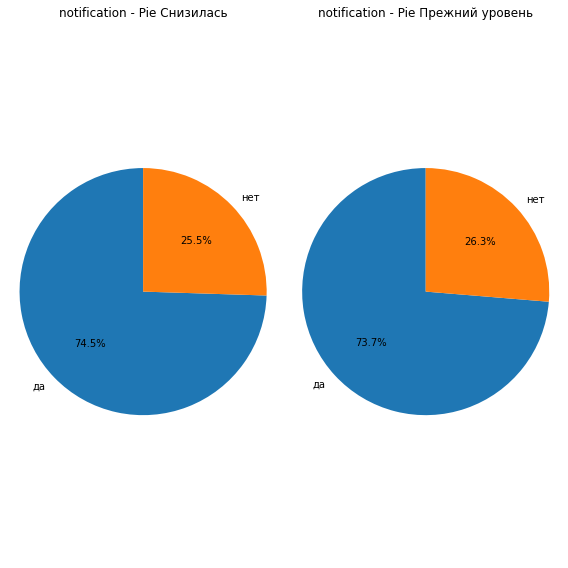

Value counts for notification (Снизилась):
да     368
нет    126
Name: notification, dtype: int64
Value counts for notification (Прежний уровень):
да     591
нет    211
Name: notification, dtype: int64


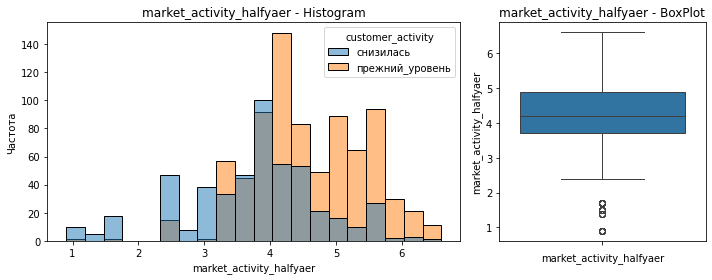


 Описание для market_activity_halfyaer:
count    1296.000000
mean        4.256404
std         1.013525
min         0.900000
25%         3.700000
50%         4.200000
75%         4.900000
max         6.600000
Name: market_activity_halfyaer, dtype: float64


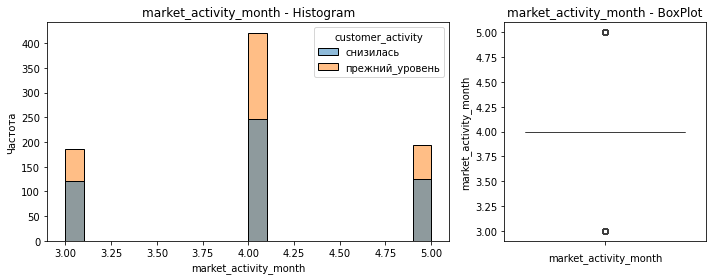


 Описание для market_activity_month:
count    1296.000000
mean        4.009259
std         0.696316
min         3.000000
25%         4.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: market_activity_month, dtype: float64


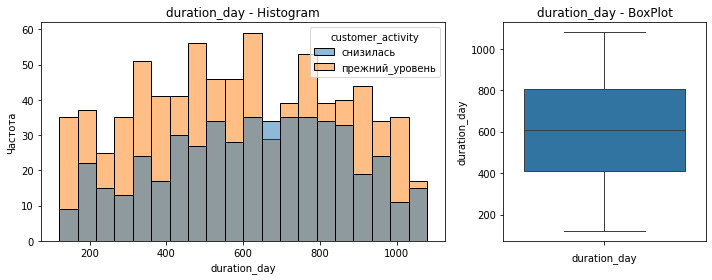


 Описание для duration_day:
count    1296.000000
mean      602.967593
std       249.195823
min       121.000000
25%       409.500000
50%       606.500000
75%       806.250000
max      1079.000000
Name: duration_day, dtype: float64


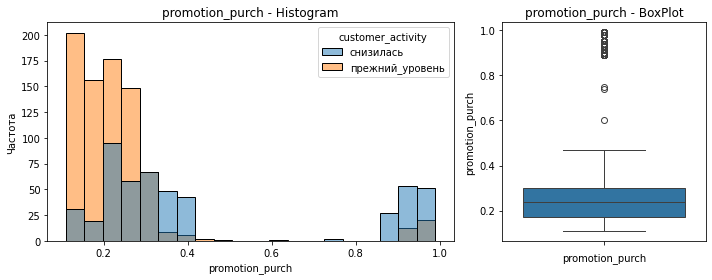


 Описание для promotion_purch:
count    1296.000000
mean        0.320069
std         0.249159
min         0.110000
25%         0.170000
50%         0.240000
75%         0.300000
max         0.990000
Name: promotion_purch, dtype: float64


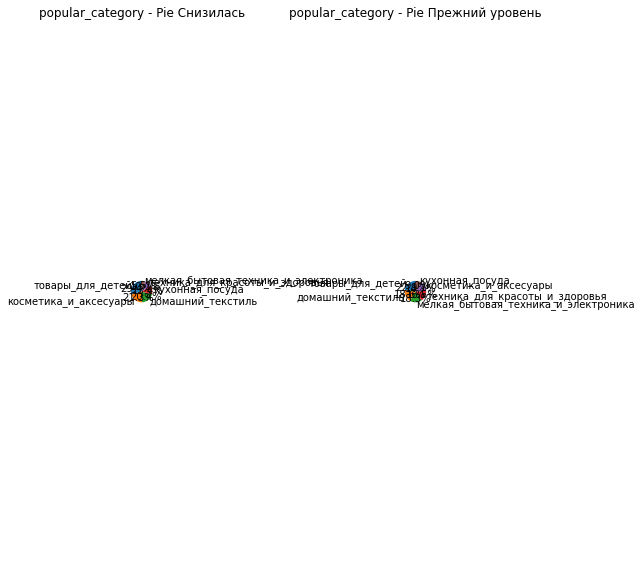

Value counts for popular_category (Снизилась):
товары_для_детей                        145
косметика_и_аксесуары                   105
домашний_текстиль                       101
кухонная_посуда                          66
техника_для_красоты_и_здоровья           50
мелкая_бытовая_техника_и_электроника     27
Name: popular_category, dtype: int64
Value counts for popular_category (Прежний уровень):
товары_для_детей                        184
домашний_текстиль                       149
мелкая_бытовая_техника_и_электроника    147
техника_для_красоты_и_здоровья          132
косметика_и_аксесуары                   118
кухонная_посуда                          72
Name: popular_category, dtype: int64


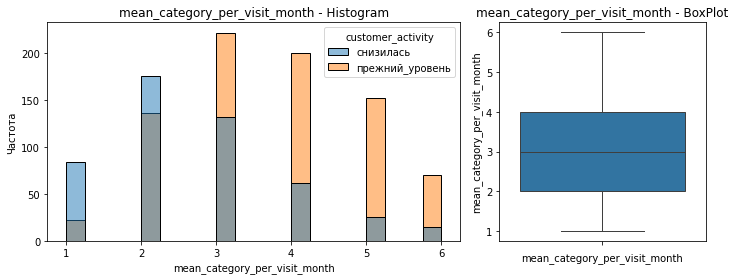


 Описание для mean_category_per_visit_month:
count    1296.000000
mean        3.267747
std         1.355125
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         6.000000
Name: mean_category_per_visit_month, dtype: float64


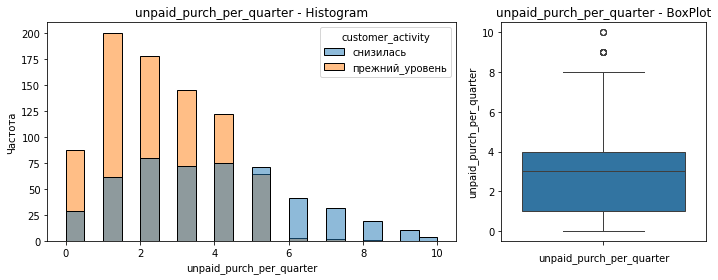


 Описание для unpaid_purch_per_quarter:
count    1296.000000
mean        2.841821
std         1.974074
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: unpaid_purch_per_quarter, dtype: float64


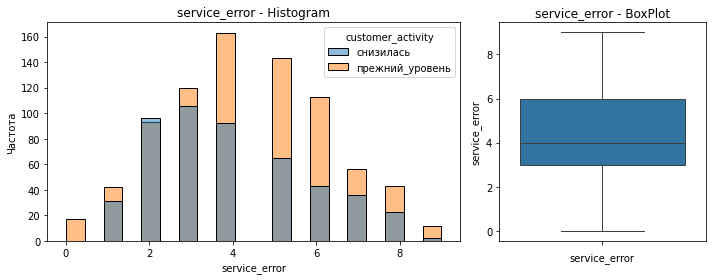


 Описание для service_error:
count    1296.000000
mean        4.184414
std         1.951719
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max         9.000000
Name: service_error, dtype: float64


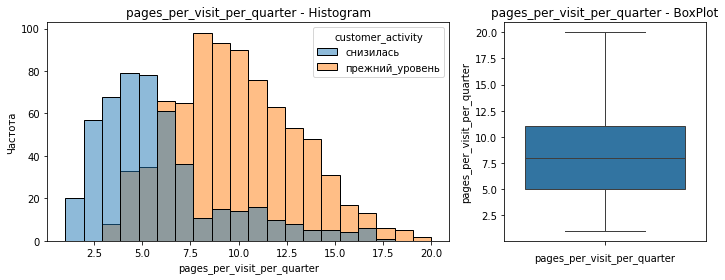


 Описание для pages_per_visit_per_quarter:
count    1296.000000
mean        8.187500
std         3.978459
min         1.000000
25%         5.000000
50%         8.000000
75%        11.000000
max        20.000000
Name: pages_per_visit_per_quarter, dtype: float64


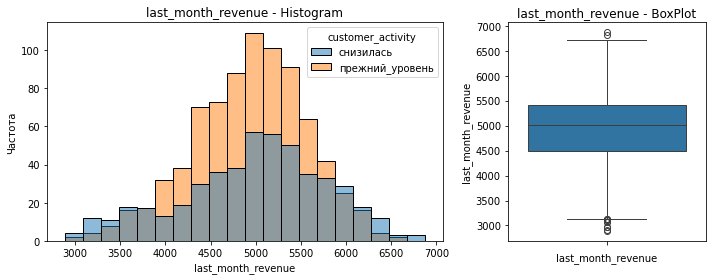


 Описание для last_month_revenue:
count    1296.000000
mean     4947.468750
std       700.797239
min      2890.000000
25%      4498.125000
50%      5005.500000
75%      5405.625000
max      6869.500000
Name: last_month_revenue, dtype: float64


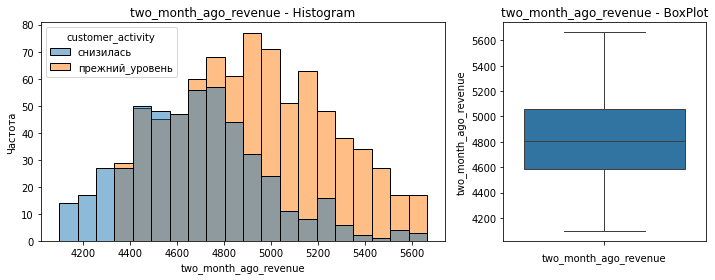


 Описание для two_month_ago_revenue:
count    1296.000000
mean     4836.202160
std       333.514091
min      4098.000000
25%      4584.500000
50%      4810.500000
75%      5056.000000
max      5663.000000
Name: two_month_ago_revenue, dtype: float64


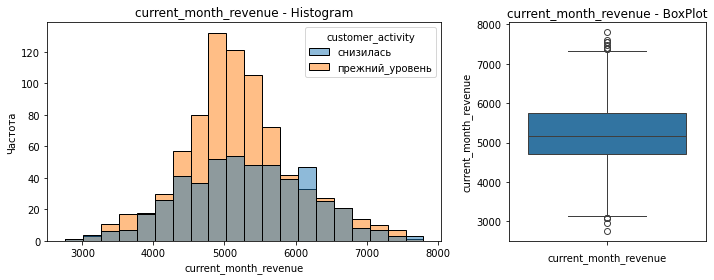


 Описание для current_month_revenue:
count    1296.000000
mean     5238.096065
std       834.318717
min      2758.700000
25%      4706.050000
50%      5179.950000
75%      5759.275000
max      7799.400000
Name: current_month_revenue, dtype: float64


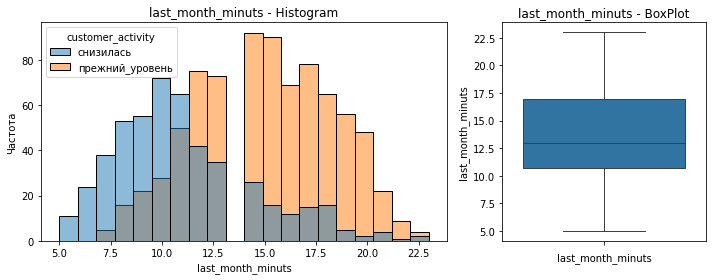


 Описание для last_month_minuts:
count    1296.000000
mean       13.470679
std         3.937630
min         5.000000
25%        10.750000
50%        13.000000
75%        17.000000
max        23.000000
Name: last_month_minuts, dtype: float64


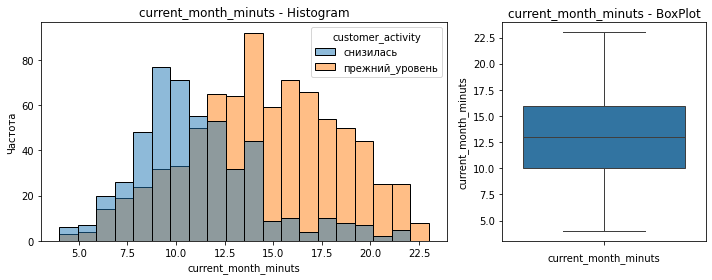


 Описание для current_month_minuts:
count    1296.000000
mean       13.210648
std         4.221794
min         4.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        23.000000
Name: current_month_minuts, dtype: float64


In [ ]:
for col in full_df.drop(columns=['id', 'customer_activity']).columns:
    if full_df[col].dtype == 'object':
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 8))

        df_low = full_df[full_df['customer_activity'] == 'снизилась']
        value_counts_low = df_low[col].value_counts()
        ax1.pie(value_counts_low.values, labels=value_counts_low.index, autopct='%1.1f%%', startangle=90)
        ax1.set_title(f'{col} - Pie Снизилась')
        ax1.axis('equal')  
        
        df_same = full_df[full_df['customer_activity'] == 'прежний_уровень']
        value_counts_same = df_same[col].value_counts()
        ax2.pie(value_counts_same.values, labels=value_counts_same.index, autopct='%1.1f%%', startangle=90)
        ax2.set_title(f'{col} - Pie Прежний уровень')
        ax2.axis('equal') 

        plt.tight_layout()
        plt.show()
        print(f"Value counts for {col} (Снизилась):")
        print(value_counts_low)
        print(f"Value counts for {col} (Прежний уровень):")
        print(value_counts_same)
        
    else:

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [2, 1]})

        sns.histplot(data=full_df, x=col, bins=20, ax=ax1, 
                     hue='customer_activity', alpha = 0.5)
        ax1.set_title(f'{col} - Histogram')
        ax1.set_xlabel(col)
        ax1.set_ylabel('Частота')

        sns.boxplot(data=full_df, y=col, ax=ax2)
        ax2.set_title(f'{col} - BoxPlot')
        ax2.set_xlabel(col)

        plt.tight_layout()
        plt.show()
        print(f"\n Описание для {col}:")
        print(full_df[col].describe())

Из полученных данных можно увидеть следующее:

- Хотя это странно, но люди с большим количеством акционных покупок чаще снижают свою активность, чем остаются на прежнем уровне;
- по категориям: чаще всего активность снижается у покупателей с любимыми категориями товары_для_детей, косметика_и_аксесуары и домашний_текстиль (прежний уровень при этом наблюдается у любителей товары_для_детей, домашний_текстиль и мелкая_бытовая_техника_и_электроника);
- активность заметно снижается у тех, кто за последний месяц посетил всего 1-2 страницы (и за последний квартал в среднем меньше 5-6);
- так же отток клинтов происходит из категории людей, у кого в корзине много не оплаченных товаров - 6-10шт;
- закономерности есть и в более очевидных вещах - активность снижается у тех, кто два месяца назад принем меньше всего прибыли, в прошлом месяце провел в среднем меньше 10 минут на сайте;
- что странно, люди с небольшим количеством ошибок (8-11), чаще отказываются от пользования сервисом, чем люди даже с большим количеством (15-22).

interval columns not set, guessing: ['market_activity_halfyaer', 'market_activity_month', 'duration_day', 'promotion_purch', 'mean_category_per_visit_month', 'unpaid_purch_per_quarter', 'service_error', 'pages_per_visit_per_quarter', 'last_month_revenue', 'two_month_ago_revenue', 'current_month_revenue', 'last_month_minuts', 'current_month_minuts']


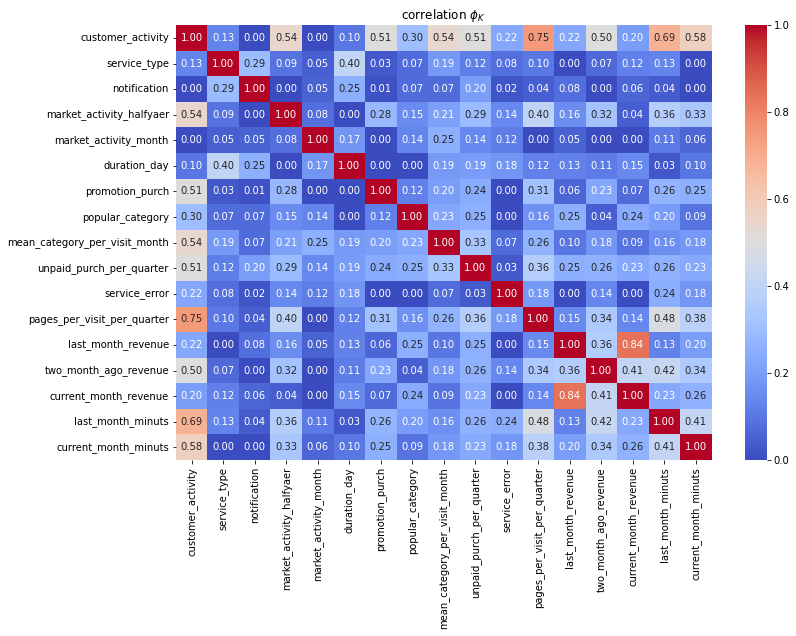

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(phik_matrix(full_df.drop(columns=['id'])), cmap='coolwarm', annot=True, fmt='.2f', annot_kws={'size':10})
plt.title('correlation $\phi_K$')
plt.show()

Посмотрим взаимосвязи целевого признака с признаками, где корреляция составляет более 0.5.

<Figure size 720x864 with 0 Axes>

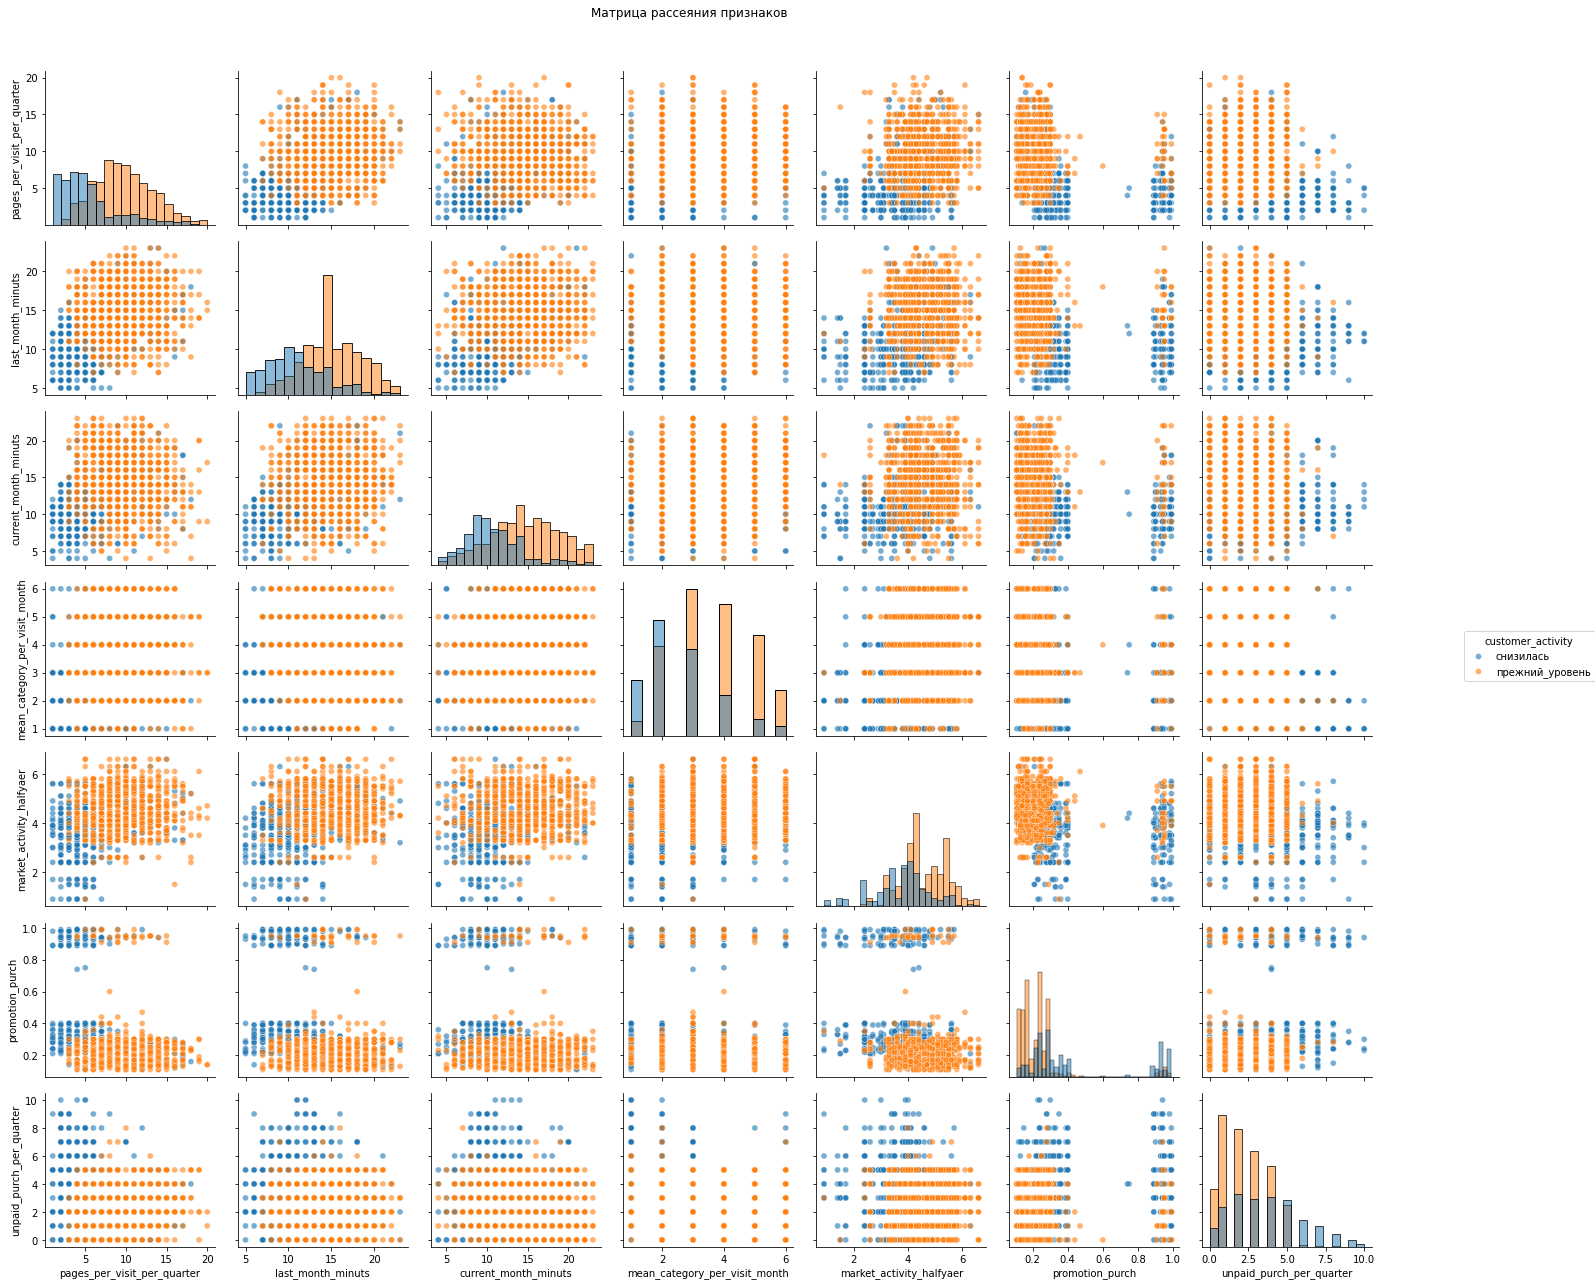

In [ ]:
key_features = ['pages_per_visit_per_quarter', 'last_month_minuts', 'current_month_minuts',
    'mean_category_per_visit_month', 'market_activity_halfyaer',
    'promotion_purch', 'unpaid_purch_per_quarter']
plt.figure(figsize=(10, 12))
g = sns.pairplot(
    full_df.drop(columns=['id']),
    vars=key_features,
    hue='customer_activity',
    plot_kws={'alpha': 0.6},
    diag_kind='hist'
)

g._legend.set_bbox_to_anchor((1.15, 0.5))
g._legend.set_frame_on(True) 
g.figure.subplots_adjust(right=0.75)
plt.suptitle('Матрица рассеяния признаков', y=1.02)
sns.set_context("notebook")
plt.tight_layout()
plt.show()

**Вывод по разделу 5.**

При проведении корреляционного анализа наблюдается достаточно высокая зависимость между активностью покупателя и количеством посещенным им страниц за последний квартал и количестве минут на сайте - что логично, но мультиколлениарности в данных нет.

Также есть большая зависимость между покупками за прошлый месяц и покупки в текущем месяце. Данные показатели важны для разработки модели и прогнозивраония активности.

Благодаря исследованию данных получилось составить портрет покупателя, у которого большая вероятность снижения активности: у него большое количество акционных покупок; любимая категория одна из товары_для_детей, косметика и акссесуары или домашний_текстиль; за последний месяц посещал 1-2 страницы и провел на сайте в среднем меньше 10 минут, за последние квартал в среднем 5-6; имеет большое количество не оплаченных товаров (6-10 шт); два месяца назад показал низкий показатель прибыли; "пострадал" от 8-11 ошибок на сайте.

## **Использование пайплайнов**

Во время подготовки данных используйте ColumnTransformer. Количественные и категориальные признаки обработайте в пайплайне раздельно. Для кодирования категориальных признаков используйте как минимум два кодировщика, для масштабирования количественных — как минимум два скейлера. Для каждой модели можно подготовить данные с разным кодированием и масштабированием.

Обучите четыре модели: KNeighborsClassifier(), DecisionTreeClassifier(), LogisticRegression() и SVC(). Для каждой из них подберите как минимум один гиперпараметр. Выберите подходящую для задачи метрику, аргументируйте свой выбор. Используйте эту метрику при подборе гиперпараметров.

Выберите лучшую модель, используя заданную метрику. Для этого примените одну из стратегий:

использовать пайплайны и инструменты подбора гиперпараметров для каждой модели отдельно, чтобы выбрать лучшую модель самостоятельно;
использовать один общий пайплайн для всех моделей и инструмент подбора гиперпараметров, который вернёт вам лучшую модель.


Метрика ROC-AUC была выбрана для подбора модели, потому что она универсальна: устойчива к дисбалансу классов, оценивает качество разделения вероятностей по всей кривой, и позволяет гибко выбирать порог принятия решений, что идеально подходит для задачи предсказания снижения активности клиентов.

In [ ]:
ohe_colum = ['notification', 'popular_category']
ord_colum = ['service_type']
num_colum = ['market_activity_halfyaer', 'market_activity_month', 'duration_day', 'promotion_purch',
            'mean_category_per_visit_month', 'unpaid_purch_per_quarter', 'service_error', 
             'pages_per_visit_per_quarter', 'last_month_revenue','two_month_ago_revenue',
             'current_month_revenue', 'last_month_minuts', 'current_month_minuts']

RANDOM_STATE = 42
TEST_SIZE = 0.25

X = full_df.drop('customer_activity', axis=1)
y = full_df['customer_activity']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, stratify=y)

In [ ]:
ohe_pipe = Pipeline(
    [('simpleimputer', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', sparse_output=False,  handle_unknown='ignore'))]
    )

ord_pipe = Pipeline(
    [('simpleimputer_after', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
      ('ord', OrdinalEncoder(categories=[['стандарт','премиум']], 
                             handle_unknown='use_encoded_value', unknown_value=np.nan)),
      ('simpleimputer_before', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))]
    )
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_colum),
    ('ord', ord_pipe, ord_colum),
    ('scaler', StandardScaler(), num_colum)], remainder='passthrough')

final_pipe = Pipeline(
    [('preprocessor', data_preprocessor),
     ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))])

param_grid = [
    
    {'models' : [DecisionTreeClassifier(random_state=RANDOM_STATE)],
    'models__max_depth' : range(2,7),
    'models__min_samples_split' : range(2,5),
    'preprocessor__scaler' : [StandardScaler(), MinMaxScaler(), 'passthrough']},
    
    {'models' : [SVC(random_state=RANDOM_STATE, probability=True)],
    'models__C' : [0.01, 0.1, 1, 10, 100],
    'models__kernel' : ['linear', 'poly', 'rbf', 'sigmoid'],
    'preprocessor__scaler' : [StandardScaler(), MinMaxScaler(), 'passthrough']}

]

randomized_search = RandomizedSearchCV(
    final_pipe, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    error_score='raise'
)
randomized_search.fit(X_train.drop(columns='id'), y_train)

print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика лучшей модели по кросс валидации:', randomized_search.best_score_)
result = pd.DataFrame(randomized_search.cv_results_)
display(result[
    ['rank_test_score', 'param_models', 'mean_test_score','params']
].sort_values('rank_test_score')) 


Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['notification',
                                                   'popular_category']),
                                                 ('ord',
                                               

,rank_test_score,param_models,mean_test_score,params
2,1,"SVC(probability=True, random_state=42)",0.900786,"{'preprocessor__scaler': MinMaxScaler(), 'mode..."
4,2,"SVC(probability=True, random_state=42)",0.896270,"{'preprocessor__scaler': StandardScaler(), 'mo..."
5,3,"SVC(probability=True, random_state=42)",0.892363,"{'preprocessor__scaler': MinMaxScaler(), 'mode..."
7,4,"SVC(probability=True, random_state=42)",0.887436,"{'preprocessor__scaler': 'passthrough', 'model..."
8,5,DecisionTreeClassifier(random_state=42),0.822975,"{'preprocessor__scaler': MinMaxScaler(), 'mode..."
0,6,DecisionTreeClassifier(random_state=42),0.821993,"{'preprocessor__scaler': StandardScaler(), 'mo..."
9,7,DecisionTreeClassifier(random_state=42),0.800320,"{'preprocessor__scaler': StandardScaler(), 'mo..."
1,8,"SVC(probability=True, random_state=42)",0.742264,"{'preprocessor__scaler': 'passthrough', 'model..."
3,9,"SVC(probability=True, random_state=42)",0.740630,"{'preprocessor__scaler': 'passthrough', 'model..."
6,10,"SVC(probability=True, random_state=42)",0.562494,"{'preprocessor__scaler': 'passthrough', 'model..."


In [ ]:
best_model = randomized_search.best_estimator_
res = roc_auc_score(y_test, best_model.predict_proba(X_test.drop(columns="id"))[:, 1])
print(f'ROC_AUC на тестовой выборвке составила {res * 100 :.2f} %')

ROC_AUC на тестовой выборвке составила 92.10 %


**Вывод по разделу 6.**

Получилось, что лучшая модель SVC (все позиции в топ-3 моделей). Лучшие параметры: preprocessor__scaler': MinMaxScaler(), 'models__kernel': 'rbf', 'models__C': 0.1, 'models': SVC(random_state=42). В следющих по ROC-AUC метрике все гиперпараметры такие же, за исключением "C".

На тестовых данный модель показала себя с точностью 92.10%.

## **Анализ важности признаков**

1. Оцените важность признаков для лучшей модели и постройте график важности с помощью метода SHAP.

2. Сделайте выводы о значимости признаков:

- какие признаки мало значимы для модели;

- какие признаки сильнее всего влияют на целевой признак;

- как можно использовать эти наблюдения при моделировании и принятии бизнес-решений.

PermutationExplainer explainer: 325it [03:32,  1.48it/s]                         


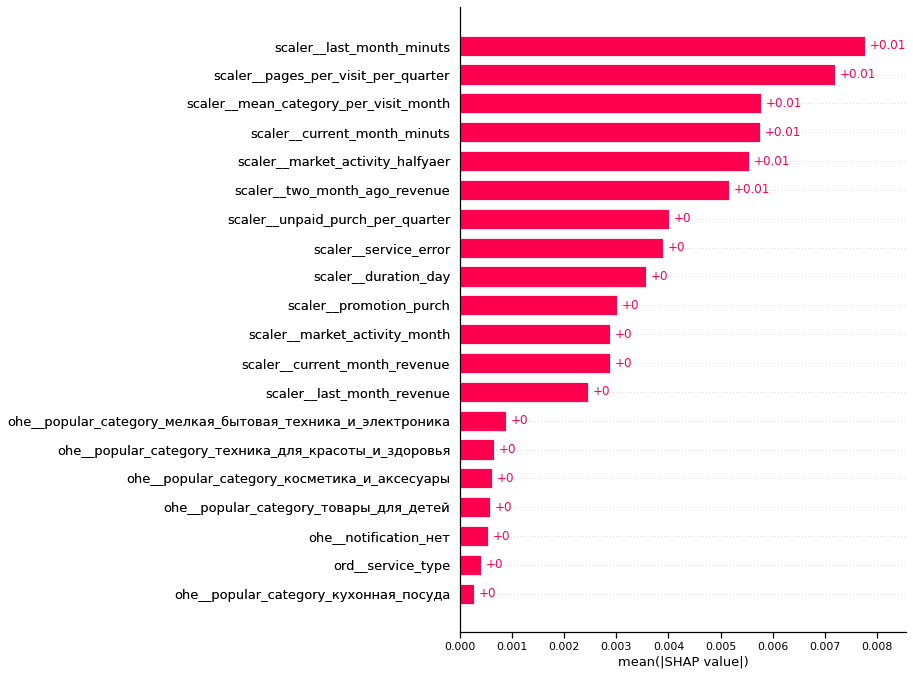

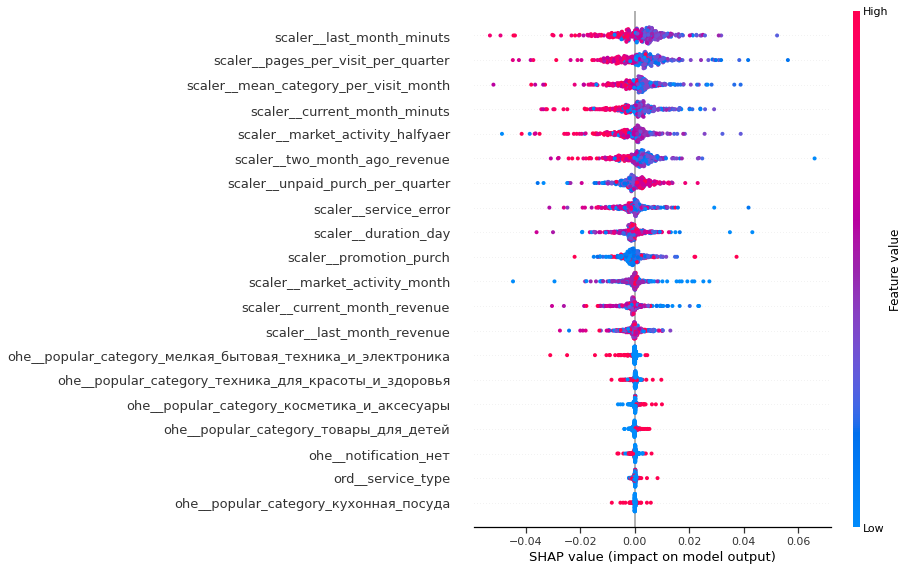

In [ ]:
X_train_processed = final_pipe.named_steps['preprocessor'].fit_transform(X_train.drop(columns='id'))
X_summary = shap.sample(X_train_processed, nsamples=50)
X_test_processed = final_pipe.named_steps['preprocessor'].transform(X_test.drop(columns='id'))
explainer = shap.Explainer(randomized_search.best_estimator_.named_steps['models'].predict_proba, X_summary)
feature_names = final_pipe.named_steps['preprocessor'].get_feature_names_out()
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)
shap_values = explainer(X_test_df)
shap.plots.bar(shap_values[..., 1], max_display=20)
shap.plots.beeswarm(shap_values[..., 1], max_display=20)

**Вывод по разделу 7.**

Подготовили данные и обучили лучшею модель по полученным гиперпараметрам. Благодаря SHAP-анализу определили следующее:

1. Для модели практически не значимы - активность со стороны маркета за месяц и категории покупок

2. Стоит отметить, что акционные покупки в большом количестве положительно влияют на сохранение активности.

Посмотрев на EDA, можно сделать вывод, и правда признаки, играющие роль в портрете "клиента со снижающейся активностью", сильно влияют на предсказаение модели. Это подтвержается на такиях критериях как: кол-во страниц за квартал, количество минут за текщий и предыдущий месяцы.

## **Сегментация покупателей**

Необходимо сделать следующее:

1. Выполните сегментацию покупателей. Используйте результаты моделирования и данные о прибыльности покупателей.
2. Выберите группу покупателей и предложите, как увеличить её покупательскую активность:
- Проведите графическое и аналитическое исследование группы покупателей.
- Сделайте предложения по работе с сегментом для увеличения покупательской активности.
3. Сделайте выводы о сегментах:
- какой сегмент вы взяли для дополнительного исследования,
- какие предложения вы сделали и почему.

In [ ]:
print(randomized_search.best_estimator_.classes_)

['прежний_уровень' 'снизилась']


In [ ]:
result_df = X_test.copy()
result_df['low_activity'] = randomized_search.best_estimator_.predict_proba(X_test)[
    :, list(randomized_search.best_estimator_.classes_).index('снизилась')
]
result_df = result_df.sort_values(by='low_activity', ascending=False)
display(result_df.head())
print(f' Клиентов, с вероятностью снижения активности >= 0.75 - {result_df[result_df.low_activity >= 0.75].shape[0]} шт из всего {result_df.shape[0]} предсказанных')

,id,service_type,notification,market_activity_halfyaer,market_activity_month,duration_day,promotion_purch,popular_category,mean_category_per_visit_month,unpaid_purch_per_quarter,service_error,pages_per_visit_per_quarter,last_month_revenue,two_month_ago_revenue,current_month_revenue,last_month_minuts,current_month_minuts,low_activity
349,215701,стандарт,да,0.9,4,212,0.95,домашний_текстиль,2,5,4,2,4685.5,4444.0,5161.3,9,7,0.999988
66,215418,стандарт,нет,1.7,4,472,0.94,домашний_текстиль,2,6,4,3,5943.5,4661.0,6427.1,8,11,0.994298
186,215538,премиум,да,1.5,5,788,0.89,товары_для_детей,1,4,4,4,6013.5,4641.0,6900.1,8,4,0.994289
276,215628,стандарт,да,4.0,4,618,0.93,товары_для_детей,3,5,2,2,3783.0,4566.0,3848.0,9,10,0.993165
273,215625,стандарт,да,4.1,4,464,0.94,косметика_и_аксесуары,2,5,1,3,5348.5,4777.0,5674.8,11,6,0.993042


 Клиентов, с вероятностью снижения активности >= 0.75 - 93 шт из всего 324 предсказанных


91 человек из 324 это очень много. Поэтому явно стоит ими заняться, иначе заказчик потеряет около 1/3 клиентов.

На следющем рассмотрим зависимость между категориями типа сервиса (премиум пакет хороший способ для удерживания клиентов), популярных категорий (может есть зависимость доходности от категорий), количества акционных товаров (тут было бы интересно посомтреть, потому что, если кол-во акционных товаров так влияет на людей, явно стоит пересмотреть политику выдачи акций/промокодов и тд.) и количество ошибок на сайте (необходимо понимать, как это влияет на отток покупателей)

Рассмотрим все эти категории через призму получемой выгоды от клиента

In [ ]:
result_df = pd.merge(result_df, money_df, on='id')
colum = ['service_type','promotion_purch','popular_category', 'service_error']

/opt/conda/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 87.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/conda/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 71.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/conda/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 35.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/conda/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/conda/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 33.3% of the points cannot be placed; y

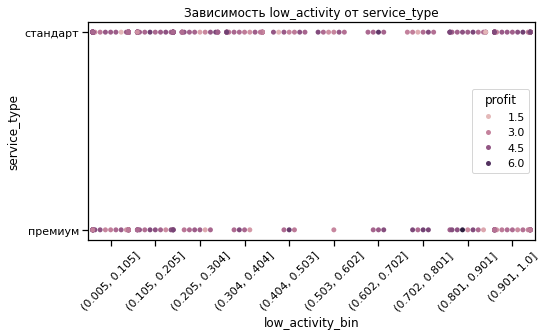

/opt/conda/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 45.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/conda/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 22.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/conda/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


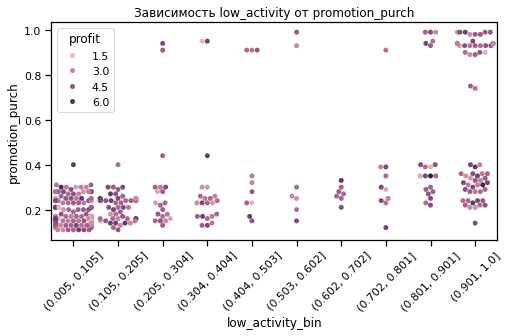

/opt/conda/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 65.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/conda/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 26.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/conda/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 53.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


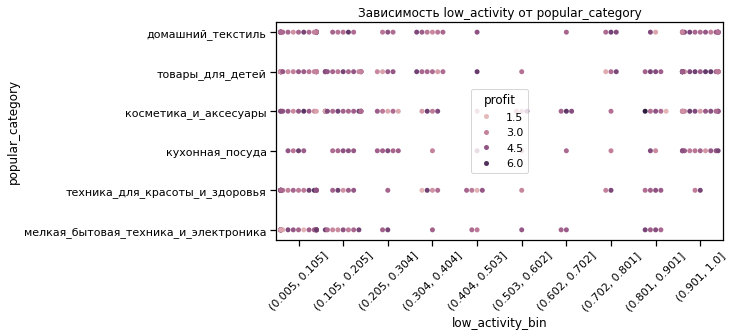

/opt/conda/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 51.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/conda/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/conda/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 29.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


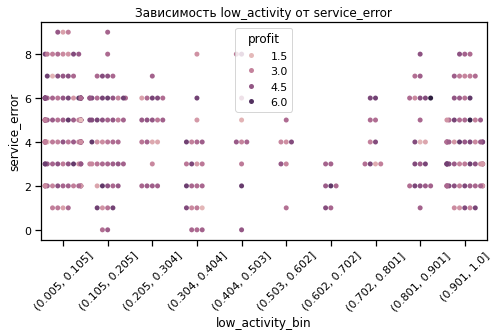

In [ ]:
result_df['low_activity_bin'] = pd.cut(result_df['low_activity'], bins=10)

for col in colum:
    plt.figure(figsize=(8, 4))
    sns.swarmplot(data=result_df, x='low_activity_bin', y=col, hue='profit', size=5)
    plt.xticks(rotation=45)
    plt.title(f'Зависимость low_activity от {col}')
    plt.show()

Можно отметить следеющее:

- Зависимости от типа сервиса практически нет - это плохо, значит компания может использовать данный инструмент, но пока что не делает этого. Прибыль от клиента распредлена с виду практически одинаково, что с подпиской, что без, что с большой долей вероятности снижения, что с малой вероятностью;
- рассматривая зависимость от доли акционных покупок заметно, что большая часть клиентов с высоким процентом акционных покупок и на грани снижения активности не приносят какой-либо заметно-отличительно-большой прибыли. Даже у клиентов с высоким уровенем вероятности снижения активности и низкой долей акционных покупок чаще встречаются высокие показатели прибыли;
- по категориям товара распредление относительно равномерное и разряженное; во всех категориях встречаются и большой профит и маленький, а так же и высокая доля вероятности снижения активности, как и низкая. Единственное, что тут можно отметить, что как и говорилось в исследовательском анализе - большего всего клиентов в катогориях товаров для детей и домашнего текстиля - там же и большое количество людей с высокой вероятностью снижения активности;
- кол-во ошибок сервиса примерно так же распределено, как у активных, так и у пользователей со снижающейся активностью.

**Вывод по разделу 7.**

Из вышесказанного можно сделать следующие выводы и дать рекомендации.

- Что магазину рекомендуется заняться сегментацией пользователей по типу подписку, потому что на этом теряется потенциальная прибыль и не используется рычаг удержания клиентов;
- неэффективность акционных клиентов показывает, что высокая доля акционных товаров не еоррелирует с высокой доходностью, а значит текущая система привлечения клиенов через акции не обеспечивает достаточнкую доходность и приток клинтов;
- равномерное распредление клиентов по оварным категориям указывает на отсутствие стимулов прибыли. Учитывая характер наиболее популярных категорий (домашний текстиль и товары для детей) можно обратить внимание не непостоянство потребоности в данных категориях. Например, товары для детей покупают, пока дети не выросли - способ удержания клиентов, предложить им то, что теперь необходимо их чаду - товары для подростов;
- несмотря на то, что кол-во ошибок не отличается от пользователей с активностью и без, очевидная рекомендация снижать кол-во ошибок, для исключения вероятности того, что это подтолкнет пользователя к отказу от сервиса.

## **Общий вывод**

В процессе работы успешно сделано:

- Библиотеки (pandas, sklearn, shap) подключены, данные загружены для анализа.
- Устранены дубликат в market_file, выбросы в market_money, опечатка в market_time.
- При. исследовательском анализе выявлено преобладание стандартного сервиса, 20% акционных покупок, лидерство «товаров для детей», около 4, 8 страниц за визит.
- Высокая корреляция активности с страницами и минутами Портрет клиента в зоне риска: высокие акционные покупки, «товары для детей» или «домашний текстиль», 1-2 страницы, меньше 10 минут, 6-10 неоплаченных товаров, 8-11 ошибок.
- Использовался пайплайн ColumnTransformer с OneHotEncoder, OrdinalEncoder, StandardScaler обработал данные. Метрика ROC-AUC (92.10% на тесте) выбрана за устойчивость к дисбалансу , лучшая модель — SVC (kernel='rbf', C=0.1).
- SHAP показал незначимость маркетинговой активности и категорий, влияние страниц и минут (утомление), положительное воздействие акций.
- Сегмент 93 клиента (из 324) с вероятностью снижения ≥ 0.75, критичный из-за «товаров для детей» и «домашний текстиль». Рекомендуются акции, скидки, снижение ошибок.

Проект для интернет-магазина «В один клик» был направлен на повышение активности постоянных клиентов. Главная цель — прогнозирование вероятности снижения активности для каждого пользователя — была успешно достигнута. На основе данных о поведении, выручке и прибыльности удалось выделить сегмент из 91 клиента из 324 с вероятностью снижения активности выше 0.75 и прибылью более 5 единиц. Этот сегмент особенно важен, так как его потеря может заметно повлиять на доход компании, особенно в категориях «товары для детей» и «домашний текстиль», где спрос подвержен сезонным изменениям или жизненным обстоятельствам, например росту детей.

Анализ показал, что клиенты с высокой вероятностью снижения активности реже покупают по акциям и чаще сталкиваются с ошибками на сайте, что требует особого внимания.

Для удержания этой группы предлагается:

- увеличить количество акционных предложений в популярных категориях;

- развивать новые категории, стимулируя переход с наиболее популярных после снижения их актуальности;

- снизить количество ошибок сервиса (сейчас около 8–11 случаев), чтобы уменьшить недовольство клиентов;

- внедрить программу лояльности, например бонусы за переход на премиум-сервис, для стабилизации дохода.

Метрика ROC-AUC на тестовой выборке составила 92,10%, что подтверждает качество модели при дисбалансе классов и ее пригодность для прогнозирования вероятности снижения активности. Лучшей моделью стала SVC с параметрами kernel='rbf' и C=0.1 в сочетании с MinMaxScaler, что обеспечило высокую точность и корректную сегментацию.

Портрет клиента из зоны риска выглядит следующим образом:

- множество покупок по акциям;

- предпочтение категорий «товары для детей», «косметика и аксессуары» или «домашний текстиль»;

- посещение 1–2 страниц в месяц, сессия менее 10 минут;

- 6–10 неоплаченных товаров;

- 8–11 ошибок на сайте.

Такие характеристики указывают на утомление клиентов и неудобства при использовании сервиса, что требует целенаправленных мер по удержанию.